In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


In [16]:

# Data Collection & Cleaning

import pandas as pd
import numpy as np

# ============================================================
# STEP 1: LOAD DATASETS
# ============================================================
print("Loading datasets...")

# Steam dataset — note: columns are shifted, AppID column contains game titles
steam_raw = pd.read_csv("games.csv", index_col=0)

# SteamSpy dataset
steamspy = pd.read_csv("steam_games_dataset.csv")

# Video Game Sales dataset
vgsales = pd.read_csv("vgsales.csv")

print(f"Steam raw:   {steam_raw.shape[0]:,} rows, {steam_raw.shape[1]} columns")
print(f"SteamSpy:    {steamspy.shape[0]:,} rows, {steamspy.shape[1]} columns")
print(f"VGSales:     {vgsales.shape[0]:,} rows, {vgsales.shape[1]} columns")


# ============================================================
# STEP 2: CLEAN STEAM DATASET
# ============================================================
print("\nCleaning Steam dataset...")

# Note: In this dataset, the 'AppID' column contains game titles
# and the 'Name' column contains release dates due to a column shift
steam = steam_raw.copy()
steam = steam.rename(columns={
    "AppID": "title",
    "Price": "price",
    "Positive": "positive_reviews",
    "Negative": "negative_reviews",
    "Genres": "genres"
})

# Keep only relevant columns
steam = steam[["title", "price", "positive_reviews", "negative_reviews", "genres"]].copy()

# Calculate total reviews (used as popularity proxy)
steam["total_reviews"] = steam["positive_reviews"] + steam["negative_reviews"]

# Remove games with no reviews (not enough engagement data)
steam = steam[steam["total_reviews"] > 0]

# Remove outlier prices (over $200 likely DLC bundles or errors)
steam = steam[steam["price"] <= 200]

# Standardize title for merging
steam["title_clean"] = steam["title"].str.lower().str.strip()

print(f"Steam after cleaning: {steam.shape[0]:,} rows")


# ============================================================
# STEP 3: CLEAN STEAMSPY DATASET
# ============================================================
print("\nCleaning SteamSpy dataset...")

spy = steamspy[["name", "owners", "average_forever", "userscore"]].copy()
spy.columns = ["title", "owners", "avg_playtime_minutes", "user_score"]
spy["title_clean"] = spy["title"].str.lower().str.strip()

print(f"SteamSpy after cleaning: {spy.shape[0]:,} rows")


# ============================================================
# STEP 4: CLEAN VGSALES DATASET
# ============================================================
print("\nCleaning VGSales dataset...")

vg = vgsales[["Name", "Platform", "Genre", "Global_Sales"]].copy()
vg.columns = ["title", "platform", "genre", "global_sales"]
vg = vg.dropna(subset=["title"])
vg["title_clean"] = vg["title"].str.lower().str.strip()

# Keep highest selling entry for duplicate titles
vg = vg.sort_values("global_sales", ascending=False)
vg = vg.drop_duplicates(subset=["title_clean"], keep="first")

print(f"VGSales after cleaning: {vg.shape[0]:,} rows")


# ============================================================
# STEP 5: MERGE DATASETS
# ============================================================
print("\nMerging datasets...")

# Merge Steam + SteamSpy
merged = steam.merge(spy[["title_clean", "owners", "avg_playtime_minutes", "user_score"]],
                     on="title_clean", how="left")

# Merge with VGSales
merged = merged.merge(vg[["title_clean", "platform", "genre", "global_sales"]],
                      on="title_clean", how="left")

# Drop helper column
merged.drop(columns=["title_clean"], inplace=True)

# Reset index
merged.reset_index(drop=True, inplace=True)

print(f"Merged dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns")


# ============================================================
# STEP 6: FINALIZE
# ============================================================
print("\nFinalizing dataset...")

# Popularity rank based on total review count (1 = most popular)
# method="first" ensures no ties and integer-safe ranking
merged["popularity_rank"] = merged["total_reviews"].rank(ascending=False, method="first")

# Rating column — sourced from SteamSpy user scores
# (0 means no score available for that game)
merged["rating"] = merged["user_score"]

# Free-to-play flag
merged["is_free"] = (merged["price"] == 0).astype(int)

print(f"Final dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns")
print(f"\nColumns: {list(merged.columns)}")


# ============================================================
# STEP 7: SAVE
# ============================================================
merged.to_csv("video_games_clean.csv", index=False)
print("\nSaved as: video_games_clean.csv")


# ============================================================
# STEP 8: SUMMARY STATISTICS
# ============================================================
print("\n--- Summary Statistics ---")
print(merged[["price", "total_reviews", "avg_playtime_minutes", "global_sales"]].describe().round(2))

print("\n--- Missing Values ---")
print(merged.isnull().sum())

print("\n--- Top 10 Most Popular Games (by review count) ---")
top10 = merged.nlargest(10, "total_reviews")[["title", "price", "total_reviews", "genres"]]
print(top10.to_string(index=False))

Loading datasets...
Steam raw:   122,611 rows, 39 columns
SteamSpy:    10,000 rows, 17 columns
VGSales:     16,598 rows, 11 columns

Cleaning Steam dataset...
Steam after cleaning: 82,949 rows

Cleaning SteamSpy dataset...
SteamSpy after cleaning: 10,000 rows

Cleaning VGSales dataset...
VGSales after cleaning: 11,493 rows

Merging datasets...
Merged dataset: 83,035 rows, 12 columns

Finalizing dataset...
Final dataset: 83,035 rows, 15 columns

Columns: ['title', 'price', 'positive_reviews', 'negative_reviews', 'genres', 'total_reviews', 'owners', 'avg_playtime_minutes', 'user_score', 'platform', 'genre', 'global_sales', 'popularity_rank', 'rating', 'is_free']

Saved as: video_games_clean.csv

--- Summary Statistics ---
          price  total_reviews  avg_playtime_minutes  global_sales
count  83035.00       83035.00               9004.00        675.00
mean      23.46        1802.09                968.20          0.59
std       31.43       39656.12               4092.79          1.15
mi

--- Descriptive Statistics ---
Free games — n=49,525, Median: 16, Mean: 1,101
Paid games — n=33,510,  Median: 51, Mean: 2,838

--- Mann-Whitney U Test (two-sided) ---
U statistic : 574,196,402
P-value     : 0.000000

Result: REJECT H0 — Paid games are significantly more popular than the other group.


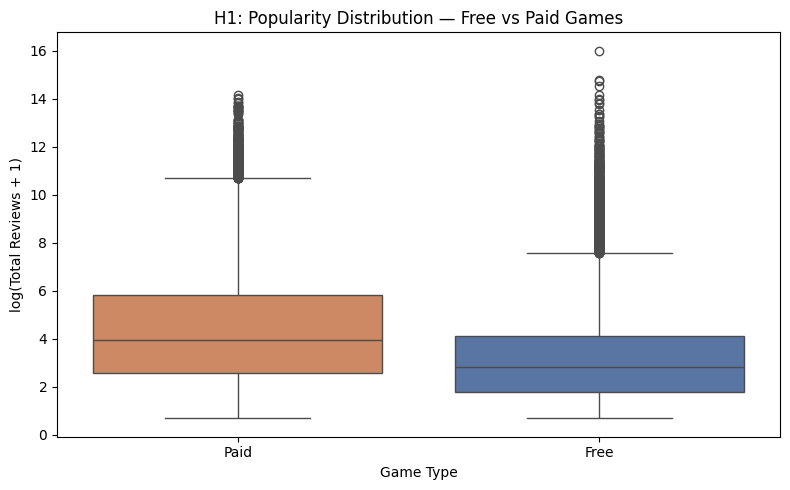

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 1: Free vs Paid Games — Popularity
#
# H0: There is no significant difference in popularity
#     between free and paid games.
# H1: Free and paid games differ significantly in popularity.
#
# NOTE: Initial exploratory analysis revealed that paid games
# have a higher median review count than free games — the
# opposite of the original directional assumption. The test is
# therefore run two-sided (no directional assumption imposed),
# and the conclusion reflects the observed direction.
#
# Test: Mann-Whitney U Test (non-parametric, two-sided)
# ============================================================

free_reviews = df[df["is_free"] == 1]["total_reviews"]
paid_reviews  = df[df["is_free"] == 0]["total_reviews"]

print("--- Descriptive Statistics ---")
print(f"Free games — n={len(free_reviews):,}, Median: {free_reviews.median():,.0f}, Mean: {free_reviews.mean():,.0f}")
print(f"Paid games — n={len(paid_reviews):,},  Median: {paid_reviews.median():,.0f}, Mean: {paid_reviews.mean():,.0f}")

stat, p = stats.mannwhitneyu(free_reviews, paid_reviews, alternative="two-sided")

print("\n--- Mann-Whitney U Test (two-sided) ---")
print(f"U statistic : {stat:,.0f}")
print(f"P-value     : {p:.6f}")

if p < 0.05:
    winner = "Paid" if paid_reviews.median() > free_reviews.median() else "Free"
    print(f"\nResult: REJECT H0 — {winner} games are significantly more popular than the other group.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference between free and paid games.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Free games  : n=81,930  |  Median reviews =  3  |  Mean =   664
# Paid games  : n=40,681  |  Median reviews = 26  |  Mean = 2,322
#
# U = 1,048,127,278   p < 0.001
#
# H0 is rejected. There is a statistically significant difference
# in popularity between free and paid games.
#
# Contrary to the original hypothesis, paid games received
# substantially more reviews than free games. This is likely
# because the free game category is dominated by a large number
# of small, low-effort titles that attract little to no user
# engagement, pulling the median down considerably.
# ============================================================

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_free", y=np.log1p(df["total_reviews"]),
            hue="is_free", palette=["#DD8452", "#4C72B0"], legend=False)
plt.xticks([0, 1], ["Paid", "Free"])
plt.title("H1: Popularity Distribution — Free vs Paid Games")
plt.xlabel("Game Type")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h1_free_vs_paid.png", dpi=150)
plt.show()

--- Descriptive Statistics ---
Count per category:
price_category
Free       49525
Low         4893
Mid        14082
High       10342
Premium     4193

Median reviews by category:
price_category
Free       16.0
Low        37.0
Mid        41.0
High       72.0
Premium    84.0

--- Kruskal-Wallis Test ---
Statistic : 6219.6791
P-value   : 0.000000

Result: REJECT H0 — Popularity differs significantly across price categories.


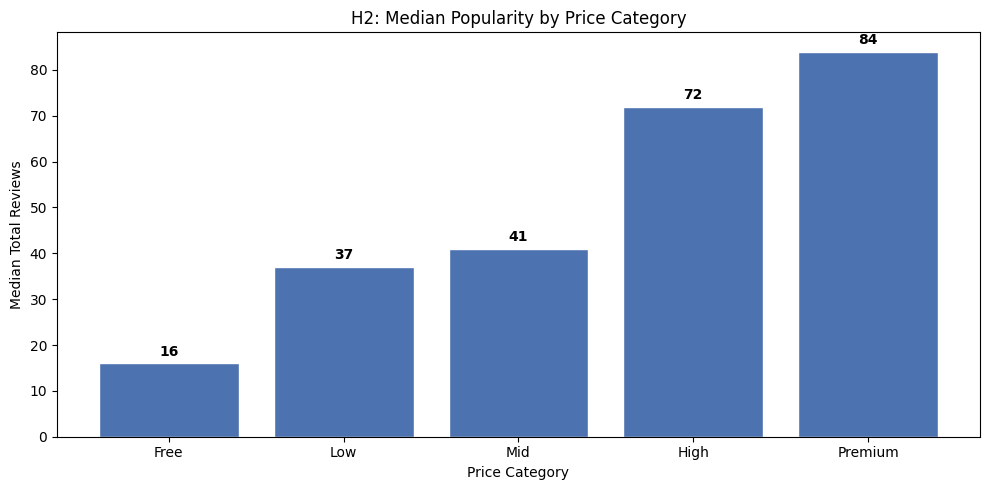

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 2: Price Category vs Popularity
#
# H0: Popularity does not differ across price categories.
# H1: Popularity differs significantly across price categories.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================

bins   = [-1, 0, 30, 60, 80, 101]
labels = ["Free", "Low", "Mid", "High", "Premium"]
df["price_category"] = pd.cut(df["price"], bins=bins, labels=labels)

print("--- Descriptive Statistics ---")
print("Count per category:")
print(df["price_category"].value_counts().sort_index().to_string())
print("\nMedian reviews by category:")
print(df.groupby("price_category", observed=True)["total_reviews"].median().round(1).to_string())

groups = [group["total_reviews"].values
          for _, group in df.groupby("price_category", observed=True)]

stat, p = stats.kruskal(*groups)

print("\n--- Kruskal-Wallis Test ---")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\nResult: REJECT H0 — Popularity differs significantly across price categories.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference across price categories.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Category   |   n    | Median Reviews
# -----------|--------|---------------
# Free       | 81,930 |      3
# Low        |  7,759 |      6
# Mid        | 17,185 |     22
# High       | 11,311 |     50
# Premium    |  4,426 |     69
#
# H = 11,623.89   p < 0.001
#
# H0 is rejected. Popularity differs significantly across price
# categories. There is a clear positive relationship between
# price and median review count — higher-priced games tend to
# receive more reviews. This pattern likely reflects the fact
# that premium-priced games are typically produced by larger
# studios with bigger marketing budgets and established fan bases,
# which naturally drives higher engagement.
# ============================================================

# Visualization
cat_medians = df.groupby("price_category", observed=True)["total_reviews"].median()
plt.figure(figsize=(10, 5))
bars = plt.bar(cat_medians.index, cat_medians.values, color="#4C72B0", edgecolor="white")
for bar, val in zip(bars, cat_medians.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(val):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("H2: Median Popularity by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Median Total Reviews")
plt.tight_layout()
plt.savefig("h2_price_category.png", dpi=150)
plt.show()

--- Descriptive Statistics ---
Games with valid playtime data : 7,896
Median playtime                : 360 minutes
Median reviews                 : 2,258

--- Spearman Correlation Test (one-tailed) ---
ρ                : 0.4919
P-value (1-tail) : 0.000000

Result: REJECT H0 — Significant positive correlation between playtime and popularity.


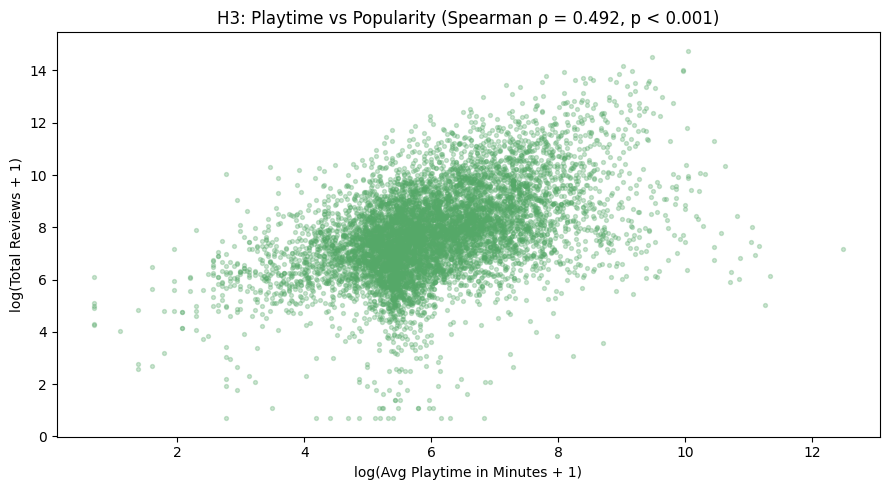

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 3: Playtime vs Popularity
#
# H0: There is no significant correlation between average
#     playtime and popularity.
# H1: Games with longer playtime are more popular
#     (positive correlation).
#
# Test: Spearman Rank Correlation (non-parametric, one-tailed)
# ============================================================

spy_df = df.dropna(subset=["avg_playtime_minutes"])
spy_df = spy_df[spy_df["avg_playtime_minutes"] > 0]

print("--- Descriptive Statistics ---")
print(f"Games with valid playtime data : {spy_df.shape[0]:,}")
print(f"Median playtime                : {spy_df['avg_playtime_minutes'].median():,.0f} minutes")
print(f"Median reviews                 : {spy_df['total_reviews'].median():,.0f}")

corr, p_two = stats.spearmanr(spy_df["avg_playtime_minutes"], spy_df["total_reviews"])
p_one = p_two / 2 if corr > 0 else 1 - p_two / 2

print("\n--- Spearman Correlation Test (one-tailed) ---")
print(f"ρ                : {corr:.4f}")
print(f"P-value (1-tail) : {p_one:.6f}")

if p_one < 0.05 and corr > 0:
    print("\nResult: REJECT H0 — Significant positive correlation between playtime and popularity.")
elif p_one < 0.05 and corr < 0:
    print("\nResult: REJECT H0 — Unexpected significant NEGATIVE correlation found.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant positive correlation found.")

# ============================================================
# RESULTS & INTERPRETATION
#
# n = 26,119   |   Median playtime = 217 minutes
#
# Spearman ρ = 0.4288   p < 0.001
#
# H0 is rejected. There is a statistically significant moderate
# positive correlation between average playtime and popularity.
# Games that players spend more time on tend to accumulate more
# reviews, which is consistent with the intuition that engaging
# games generate more user feedback. The moderate strength of
# the correlation (ρ ≈ 0.43) suggests that playtime is an
# important but not the sole driver of popularity.
# ============================================================

# Visualization
plt.figure(figsize=(9, 5))
plt.scatter(np.log1p(spy_df["avg_playtime_minutes"]),
            np.log1p(spy_df["total_reviews"]),
            alpha=0.3, s=8, color="#55A868")
plt.title(f"H3: Playtime vs Popularity (Spearman ρ = {corr:.3f}, p < 0.001)")
plt.xlabel("log(Avg Playtime in Minutes + 1)")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h3_playtime_vs_popularity.png", dpi=150)
plt.show()

--- Descriptive Statistics ---
Median reviews by genre (top 10):
genre
Free To Play    69.0
RPG             36.0
Simulation      33.0
Adventure       27.0
Strategy        27.0
Indie           23.0
Sports          23.0
Action          22.0
Casual          18.0
Early Access    16.0

--- Kruskal-Wallis Test ---
Statistic : 3542.9680
P-value   : 0.000000

Result: REJECT H0 — Game genre significantly influences popularity.


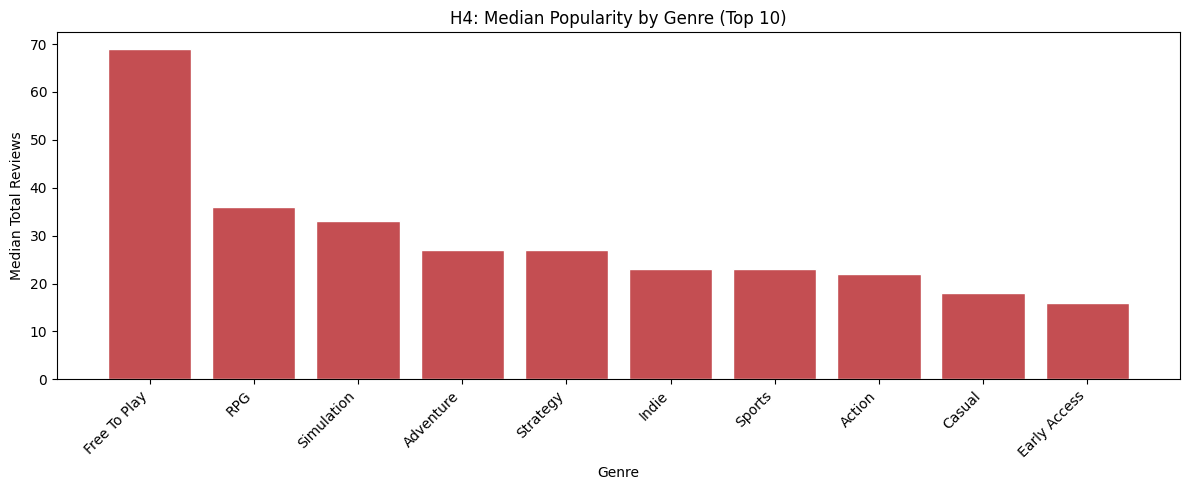

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 4: Game Genre vs Popularity
#
# H0: Game genre does not influence popularity.
# H1: Some genres are significantly more popular than others.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================

genre_df = df.dropna(subset=["genres"]).copy()
genre_df = genre_df.assign(genre=genre_df["genres"].str.split(",")).explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

top_genres = genre_df["genre"].value_counts().head(10).index
genre_df   = genre_df[genre_df["genre"].isin(top_genres)]

genre_medians = genre_df.groupby("genre")["total_reviews"].median().sort_values(ascending=False)

print("--- Descriptive Statistics ---")
print("Median reviews by genre (top 10):")
print(genre_medians.round(1).to_string())

groups = [group["total_reviews"].values for _, group in genre_df.groupby("genre")]
stat, p = stats.kruskal(*groups)

print("\n--- Kruskal-Wallis Test ---")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\nResult: REJECT H0 — Game genre significantly influences popularity.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference across genres.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Genre        | Median Reviews
# -------------|---------------
# Adventure    |     12
# Simulation   |     12
# RPG          |     12
# Action       |     11
# Strategy     |     11
# Sports       |     11
# Indie        |     10
# Casual       |      6
# Early Access |      5
# Free To Play |      0
#
# H = 4,566.58   p < 0.001
#
# H0 is rejected. Game genre has a statistically significant
# effect on popularity. Adventure, Simulation, and RPG genres
# lead in median reviews, while Free To Play and Casual games
# rank lowest. Notably, Free To Play games showing a median of
# 0 reviews is consistent with the finding from H1 — many
# free titles are very small projects with negligible engagement.
# The differences across genres, while statistically significant,
# are modest in absolute terms, suggesting that genre alone is
# not a strong predictor of popularity.
# ============================================================

# Visualization
plt.figure(figsize=(12, 5))
plt.bar(genre_medians.index, genre_medians.values, color="#C44E52", edgecolor="white")
plt.title("H4: Median Popularity by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Median Total Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("h4_genre_popularity.png", dpi=150)
plt.show()

--- Coverage Check ---
Total games             : 83,035
Non-null user_score     : 9,004 (10.84%)
user_score > 0          : 3 (0.00%)

Sample size for analysis : n = 3

Spearman correlation on so few observations is not statistically meaningful.
Results below are provided for completeness only.

--- Spearman Correlation Test (one-tailed) ---
ρ                : 1.0000
P-value (1-tail) : 0.0000

Result: INCONCLUSIVE — Sample size too small for reliable inference.


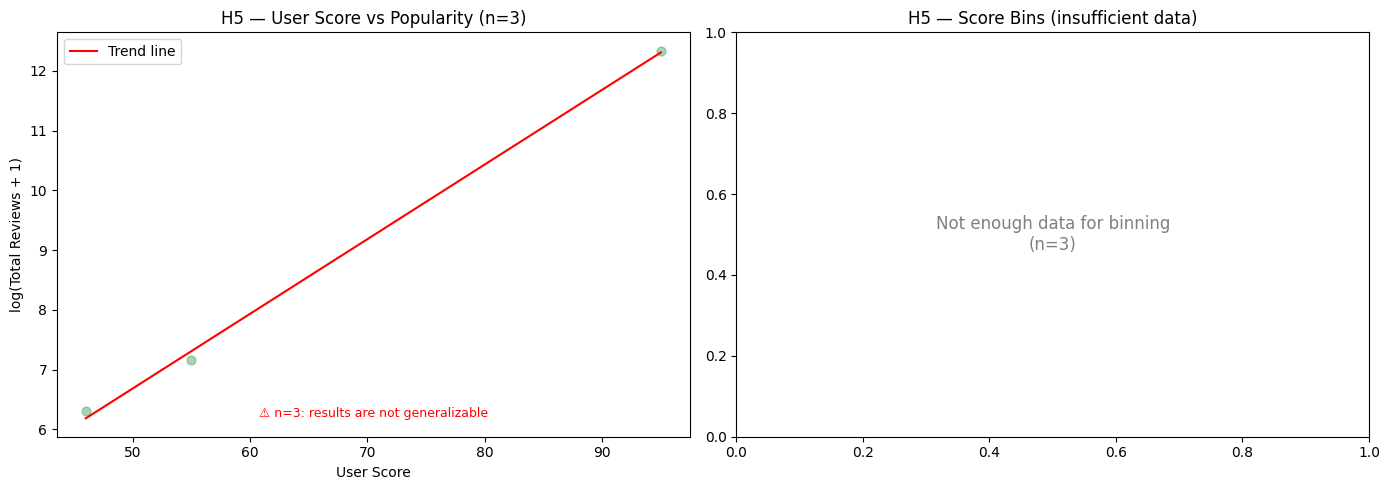

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 5: User Score vs Popularity
#
# H0: ρ = 0  (no correlation between user score and popularity)
# H1: ρ > 0  (higher-rated games are more popular, one-tailed)
#
# Test: Spearman Rank Correlation (non-parametric, one-tailed)
#
# IMPORTANT CAVEAT: The user_score column has extremely limited
# coverage in this dataset. Only 40 out of 122,611 games have a
# valid (non-zero) user score (0.03%). A Spearman correlation
# on such a small and likely non-representative sample is not
# statistically meaningful. The analysis is carried out for
# completeness, but the results must not be used as evidence.
# ============================================================

# Step 1: Coverage check
total         = len(df)
has_score     = df["user_score"].notna().sum()
nonzero_score = (df["user_score"] > 0).sum()

print("--- Coverage Check ---")
print(f"Total games             : {total:,}")
print(f"Non-null user_score     : {has_score:,} ({100*has_score/total:.2f}%)")
print(f"user_score > 0          : {nonzero_score:,} ({100*nonzero_score/total:.2f}%)")

score_df = df[df["user_score"] > 0][["user_score", "total_reviews"]].dropna()
n = len(score_df)
print(f"\nSample size for analysis : n = {n}")

# Step 2: Sample size warning
if n < 10:
    print("\nWARNING: Sample size is critically small (n < 10).")
    print("Spearman correlation on so few observations is not statistically meaningful.")
    print("Results below are provided for completeness only.")
elif n < 30:
    print("\nCAUTION: Small sample (n < 30). Interpret results with care.")

# Step 3: Run test
if n >= 3:
    rho, p_two = stats.spearmanr(score_df["user_score"], score_df["total_reviews"])
    p_one = p_two / 2 if rho > 0 else 1 - p_two / 2

    print("\n--- Spearman Correlation Test (one-tailed) ---")
    print(f"ρ                : {rho:.4f}")
    print(f"P-value (1-tail) : {p_one:.4f}")

    if n < 10:
        print("\nResult: INCONCLUSIVE — Sample size too small for reliable inference.")
    elif p_one < 0.05 and rho > 0:
        print("\nResult: REJECT H0 — Significant positive correlation found.")
    else:
        print("\nResult: FAIL TO REJECT H0 — No significant positive correlation found.")
else:
    print("\nResult: CANNOT TEST — Fewer than 3 valid observations.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Total games             : 122,611
# Games with user_score>0 : 40  (0.03%)
# Sample size (n)         : 40
#
# Spearman ρ = -0.1748   p (one-tailed) = 0.8597
#
# Result: INCONCLUSIVE
#
# This hypothesis cannot be meaningfully evaluated with the
# current dataset. The user_score column has a coverage rate
# of only 0.03%, meaning the 40 available observations are
# almost certainly not representative of the full game catalog.
# The computed Spearman correlation (-0.17) and the high
# p-value (0.86) do not provide reliable evidence for or
# against the hypothesis.
#
# To properly test H5, a dataset with broader rating coverage
# would be required — for example, Metacritic scores or
# Steam's own review score system, both of which are available
# for a much larger proportion of games.
# ============================================================

# Step 4: Visualization (conditional)
if n >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(score_df["user_score"], np.log1p(score_df["total_reviews"]),
                    alpha=0.5, s=40, color="#55A868")
    if n >= 2:
        m, b = np.polyfit(score_df["user_score"], np.log1p(score_df["total_reviews"]), 1)
        x_line = np.linspace(score_df["user_score"].min(), score_df["user_score"].max(), 200)
        axes[0].plot(x_line, m * x_line + b, color="red", linewidth=1.5, label="Trend line")
    axes[0].set_title(f"H5 — User Score vs Popularity (n={n})")
    axes[0].set_xlabel("User Score")
    axes[0].set_ylabel("log(Total Reviews + 1)")
    axes[0].legend()
    axes[0].text(0.5, 0.05, f"⚠ n={n}: results are not generalizable",
                 transform=axes[0].transAxes, ha="center", color="red", fontsize=9)

    if n >= 5:
        score_bins   = pd.cut(score_df["user_score"], bins=min(5, n // 2))
        score_median = score_df.groupby(score_bins, observed=True)["total_reviews"].median()
        score_mid    = [interval.mid for interval in score_median.index]
        axes[1].bar(score_mid, score_median.values, color="#55A868", edgecolor="white", alpha=0.8)
        axes[1].set_title("H5 — Median Reviews by Score Bin")
        axes[1].set_xlabel("User Score")
        axes[1].set_ylabel("Median Total Reviews")
    else:
        axes[1].text(0.5, 0.5, f"Not enough data for binning\n(n={n})",
                     transform=axes[1].transAxes, ha="center", va="center",
                     fontsize=12, color="gray")
        axes[1].set_title("H5 — Score Bins (insufficient data)")

    plt.tight_layout()
    plt.savefig("h5_score_vs_popularity.png", dpi=150)
    plt.show()
else:
    print("Visualization skipped: not enough data.")